In [ ]:
%%capture
!pip install fairlearn

In [ ]:
import numpy as np
from IPython.display import display, Markdown, Latex
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.adversarial import AdversarialFairnessClassifier
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)

## NOTE: If the top two cells give you errors:
### 1. Open `Runtime` in the top bar
### 2. Press `Restart session`
### 3. Try running the cells again
#### (This is not the same thing as reloading the page!)

(if this still doesn't work, post a **private** message on Piazza or come to our office hours)

# Load and preprocess the data

In [ ]:
#@markdown Load and read about the dataset.
# get datast from fairlearn and show description
dataset = fdata.fetch_diabetes_hospital()

display(Markdown(dataset.DESCR))

# save dataframe and features
x_raw = dataset.data
# y_raw = np.array(dataset.target)
feature_names = dataset.feature_names

The "Diabetes 130-Hospitals" dataset represents 10 years of clinical care at 130 U.S. hospitals and delivery networks, collected from 1999 to 2008. Each record represents the hospital admission record for a patient diagnosed with diabetes whose stay lasted between one to fourteen days. The features describing each encounter include demographics, diagnoses, diabetic medications, number of visits in the year preceding the encounter, and payer information, as well as whether the patient was readmitted after release, and whether the readmission occurred within 30 days of the release.

The original "Diabetes 130-Hospitals" dataset was collected by Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore in 2014.

This version of the dataset was derived by the Fairlearn team for the SciPy 2021 tutorial "Fairness in AI Systems: From social context to practice using Fairlearn". In this version, the target variable "readmitted" is binarized into whether the patient was re-admitted within thirty days. The full dataset pre-processing script can be found on GitHub: https://github.com/fairlearn/talks/blob/main/2021_scipy_tutorial/preprocess.py

Downloaded from openml.org.

You can read more about the dataset [here](https://fairlearn.org/main/user_guide/datasets/diabetes_hospital_data.html). In this description, we see that two features, `readmitted` and `readmit_binary`, are other representations of the same outcome, so we drop them from the set of predictors.

In [ ]:
#@markdown Down sample to make runtimes reasonable
x_raw = x_raw.sample(frac=0.1, random_state=123)

In [ ]:
y_raw = x_raw['readmit_binary']
x_raw = x_raw.drop(columns=['readmitted', 'readmit_binary'])
feature_names = feature_names[:-2]

In [ ]:
#@markdown Look at the first few rows of the data.
x_raw.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days
65884,Caucasian,Male,'Over 60 years','Discharged to Home',Emergency,3,Missing,49,6,27,...,None,None,Up,Ch,Yes,False,False,False,True,False
86278,Caucasian,Female,'Over 60 years',Other,Referral,5,Missing,57,0,21,...,None,None,No,Ch,Yes,True,False,False,True,False
30000,Caucasian,Male,'30-60 years','Discharged to Home',Other,4,Other,37,2,9,...,None,None,No,No,No,False,False,False,False,False
51185,Caucasian,Male,'30-60 years',Other,Other,9,InternalMedicine,61,6,27,...,None,>8,No,Ch,Yes,False,False,True,False,True
53902,Caucasian,Female,'30-60 years','Discharged to Home',Referral,7,Other,23,0,13,...,None,None,No,No,Yes,True,False,True,True,False


In [ ]:
# check how many 'Unknown/Invalid' values there are for gender
(x_raw.gender == 'Unknown/Invalid').sum()

np.int64(0)

In [ ]:
# drop these 3 rows
print(x_raw.shape)
rows_to_keep = x_raw.gender != 'Unknown/Invalid'
x_raw = x_raw[rows_to_keep]
y_raw = y_raw[rows_to_keep]
print(x_raw.shape)

(10177, 22)
(10177, 22)


In [ ]:
x_raw.dtypes

,0
race,object
gender,object
age,object
discharge_disposition_id,object
admission_source_id,object
time_in_hospital,int64
medical_specialty,object
num_lab_procedures,int64
num_procedures,int64
num_medications,int64


In [ ]:
unique_feature_values = x_raw.apply(lambda col: col.unique())
unique_feature_values

,0
race,"[Caucasian, AfricanAmerican, Unknown, Other, A..."
gender,"[Male, Female]"
age,"['Over 60 years', '30-60 years', '30 years or ..."
discharge_disposition_id,"['Discharged to Home', Other]"
admission_source_id,"[Emergency, Referral, Other]"
time_in_hospital,"[3, 5, 4, 9, 7, 8, 11, 2, 1, 6, 12, 13, 14, 10]"
medical_specialty,"[Missing, Other, InternalMedicine, Emergency/T..."
num_lab_procedures,"[49, 57, 37, 61, 23, 65, 47, 35, 51, 22, 46, 4..."
num_procedures,"[6, 0, 2, 1, 3, 4, 5]"
num_medications,"[27, 21, 9, 13, 40, 17, 34, 10, 19, 11, 6, 14,..."


In [ ]:
#@markdown
binary_features = unique_feature_values.index[[len(x) == 2 for x in unique_feature_values]].values
print(f'Binary features: {binary_features}')
categorical_features = unique_feature_values.index[[len(x) > 2 and isinstance(x[0], str) for x in unique_feature_values]].values
print(f'Categorical features: {categorical_features}')

Binary features: ['gender' 'discharge_disposition_id' 'change' 'diabetesMed' 'medicare'
 'medicaid' 'had_emergency' 'had_inpatient_days' 'had_outpatient_days']
Categorical features: ['race' 'age' 'admission_source_id' 'medical_specialty'
 'primary_diagnosis' 'max_glu_serum' 'A1Cresult' 'insulin']


In [ ]:
#@markdown
for col_name in feature_names:
    if col_name in categorical_features:
        x_raw[col_name] = x_raw[col_name].astype('category')
    elif col_name in binary_features:  # redundant for clarity
        # turn into int column
        integer_col = (x_raw[col_name] == unique_feature_values[col_name][0]).astype(int)
        new_name = f'{col_name}_{unique_feature_values[col_name][0]}'
        x_raw[new_name] = integer_col
        x_raw.drop(columns=[col_name], inplace=True)

In [ ]:
#@markdown
%%capture
x_raw.apply(lambda col: col.unique())


In [ ]:
x_raw.dtypes

,0
race,category
age,category
admission_source_id,category
time_in_hospital,int64
medical_specialty,category
num_lab_procedures,int64
num_procedures,int64
num_medications,int64
primary_diagnosis,category
number_diagnoses,int64


In [ ]:
#@markdown One-hot encode categorical features
x_numeric = pd.get_dummies(x_raw)
display(x_numeric.head())

# get one-hot and numeric column names
numeric_cols = x_numeric.dtypes.index[x_numeric.dtypes == 'float64'].values
one_hot_cols = x_numeric.dtypes.index[x_numeric.dtypes != 'float64'].values

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,gender_Male,discharge_disposition_id_'Discharged to Home',change_Ch,diabetesMed_Yes,medicare_False,...,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up
65884,3,49,6,27,9,1,1,1,1,1,...,True,False,False,False,True,False,False,False,False,True
86278,5,57,0,21,9,0,0,1,1,0,...,True,False,False,False,True,False,False,True,False,False
30000,4,37,2,9,5,1,1,0,0,1,...,True,False,False,False,True,False,False,True,False,False
51185,9,61,6,27,9,1,0,1,1,1,...,True,False,False,True,False,False,False,True,False,False
53902,7,23,0,13,7,0,1,0,1,0,...,True,False,False,False,True,False,False,True,False,False


In [ ]:
#@markdown ## TODO: Split train, test, validation data 70 train/20 test/10 val
x_train, x_temp, y_train, y_temp = train_test_split(x_numeric, y_raw, test_size=0.3, random_state=123, stratify=y_raw)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=2/3, random_state=123, stratify=y_temp)


In [ ]:
#@markdown ## TODO: Initialize Fairlearn Metric Dictrs and sensitive features


metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'False positive rate': false_positive_rate,
    'False negative rate': false_negative_rate
}
fairness_metrics = {
    'False negative rate difference': false_negative_rate_difference,
    'False positive rate difference': false_positive_rate_difference,
    'Demographic parity ratio': demographic_parity_ratio,
    'Equalized odds ratio': equalized_odds_ratio,
    'Selection rate difference': selection_rate_difference
}

sensitive_features = x_numeric['gender_Male']


# Problem 2, Part (a)
### **Train a baseline Random Forest (RF) (sklearn RandomForestClassifier) model and report metrics**

### Train a random forest model - Baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)


### Report metrics



In [ ]:
#@markdown ### Calculate metrics with Fairlearn MetricFrame
sensitive_features_test = sensitive_features.loc[x_test.index]

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_features_test)
fairness_results = {
    name: func(y_test, y_pred, sensitive_features=sensitive_features_test)
    for name, func in fairness_metrics.items()
}

In [ ]:
#@markdown Print Results

display(metric_frame.by_group)
display(pd.Series(metric_frame.overall).to_frame("Overall"))
display(pd.DataFrame([fairness_results]))


,Accuracy,Precision,Recall,False positive rate,False negative rate
gender_Male,,,,,
0,0.612319,0.634660,0.499079,0.278075,0.500921
1,0.600858,0.544872,0.425000,0.266917,0.575000


,Overall
Accuracy,0.607073
Precision,0.596752
Recall,0.467656
False positive rate,0.272644
False negative rate,0.532344


,False negative rate difference,False positive rate difference,Demographic parity ratio,Equalized odds ratio,Selection rate difference
0,0.074079,0.011158,0.865526,0.851568,0.052011


In [ ]:
#@markdown # Problem 2, Part (b)
#@markdown ### **Hyperparameter tuning of baseline RF model**
from sklearn.metrics import roc_auc_score

def tune_random_forest(x_train, y_train, x_val, y_val, max_depth, n_estimators, verbose=False, weights=None):
    '''Tunes logistic regression models over the hyperparameters max depth and n_estimators
       to maximize the AUC'''
    best_auc = 0
    best_rf = None
    for depth in max_depth:
        for n in n_estimators:
            rf = RandomForestClassifier(max_depth=depth, n_estimators=n, random_state=123)
            rf.fit(x_train, y_train)
            auc = roc_auc_score(y_val, rf.predict_proba(x_val)[:,1])
            if auc > best_auc:
                best_auc = auc
                best_rf = rf
    print(f'Best AUC: {best_auc}')
    return best_auc, best_rf

In [ ]:
#@markdown Tuning loop across different seeds
from sklearn.metrics import f1_score

def compute_metrics(model, X_test, y_test, sensitive_features):
    y_pred = model.predict(X_test)
    metric_frame = MetricFrame(
        metrics=metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_features
    )
    return metric_frame.by_group, metric_frame.overall, y_pred


max_depth = [5, 10, 15]
n_estimators = [100, 200, 300]

baseline_metrics = {metric: [] for metric in metrics.keys() | fairness_metrics.keys()}
tuned_metrics = {metric: [] for metric in metrics.keys() | fairness_metrics.keys()}

num_seeds = 10

for i in range(num_seeds):
    print(f"Processing seed {i+1}/{num_seeds}")

    x_train, x_temp, y_train, y_temp = train_test_split(
        x_numeric, y_raw, test_size=0.3, random_state=123 + i, stratify=y_raw
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=2/3, random_state=123 + i, stratify=y_temp
    )
    baseline_rf = RandomForestClassifier(random_state=123)
    baseline_rf.fit(x_train, y_train)
    base_by_group, base_overall, base_pred = compute_metrics(
        baseline_rf, x_test, y_test, x_test['gender_Male']
    )

    for metric_name in metrics.keys():
        baseline_metrics[metric_name].append(base_overall[metric_name])

    for name, func in fairness_metrics.items():
        baseline_metrics[name].append(func(y_test, base_pred, sensitive_features=x_test['gender_Male']))

    _, best_rf_tuned = tune_random_forest(x_train, y_train, x_val, y_val, max_depth, n_estimators)
    tuned_by_group, tuned_overall, tuned_pred = compute_metrics(
        best_rf_tuned, x_test, y_test, x_test['gender_Male']
    )

    for metric_name in metrics.keys():
        tuned_metrics[metric_name].append(tuned_overall[metric_name])

    for name, func in fairness_metrics.items():
        tuned_metrics[name].append(func(y_test, tuned_pred, sensitive_features=x_test['gender_Male']))

print("\nTuning loop complete.")


Processing seed 1/10
Best AUC: 0.6260591452314691
Processing seed 2/10
Best AUC: 0.6551038864759332
Processing seed 3/10
Best AUC: 0.666755939558371
Processing seed 4/10
Best AUC: 0.6491264841618246
Processing seed 5/10
Best AUC: 0.6706179624820969
Processing seed 6/10
Best AUC: 0.64467836529691
Processing seed 7/10
Best AUC: 0.6362478991759725
Processing seed 8/10
Best AUC: 0.6585622406719532
Processing seed 9/10
Best AUC: 0.6575336617023176
Processing seed 10/10
Best AUC: 0.661170561681746

Tuning loop complete.


Implement code to tune the hyperparameters of the baseline random forest
model, tuning it for accuracy. Remember to use the validation set to select the best
hyperparameters. Then, for ten different train/validation/test splits, report the same
ten metrics as above, calculated before and after hyperparameter tuning on the test set.
Show performance in a plot; we suggest using a box-and-whiskers plot for this. In your report, discuss the impact of hyperparameter tuning on fairness and accuracy for
the random forest model, and hypothesize about why certain parameters led to more
accurate/precise/fair models.

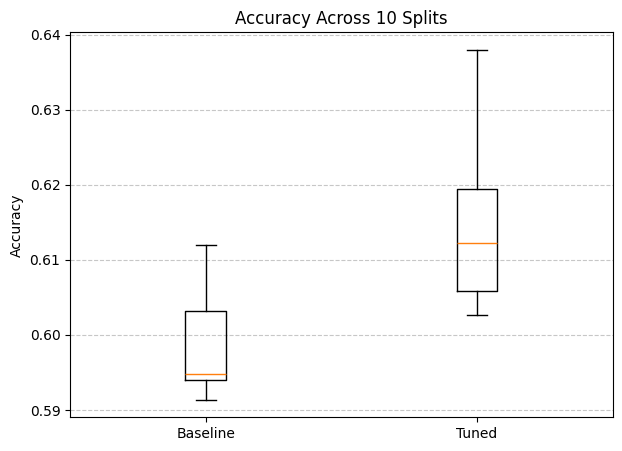

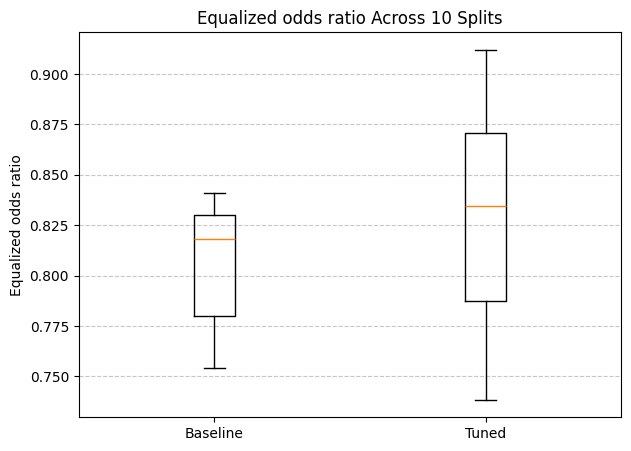

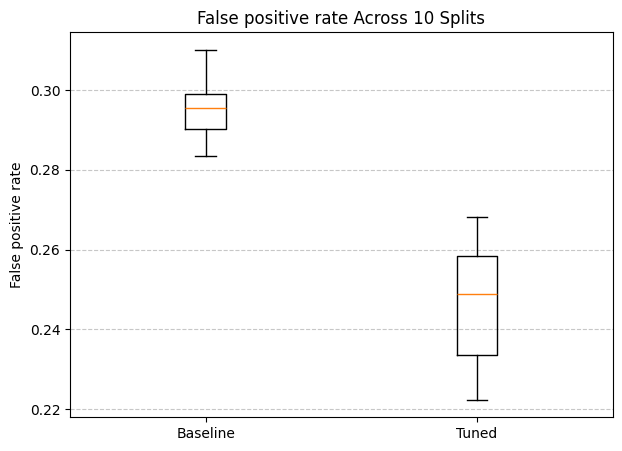

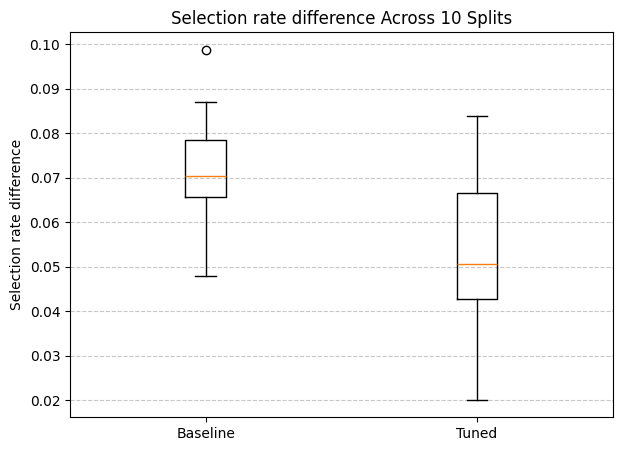

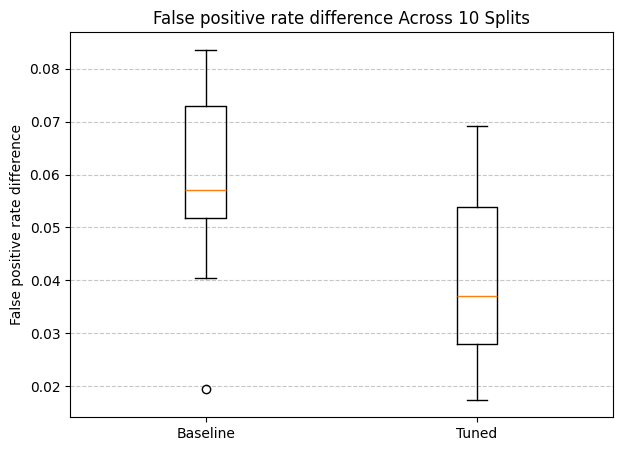

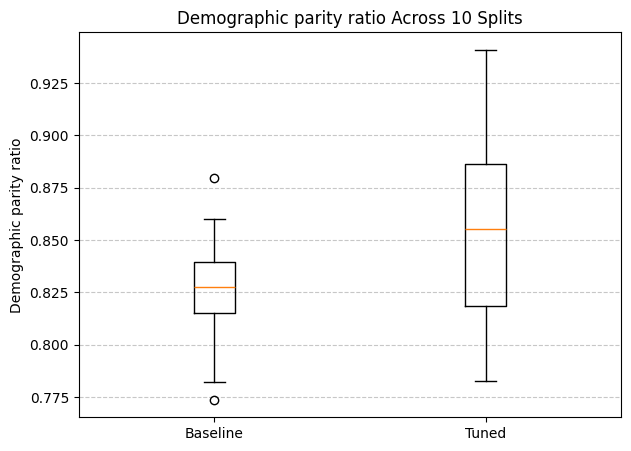

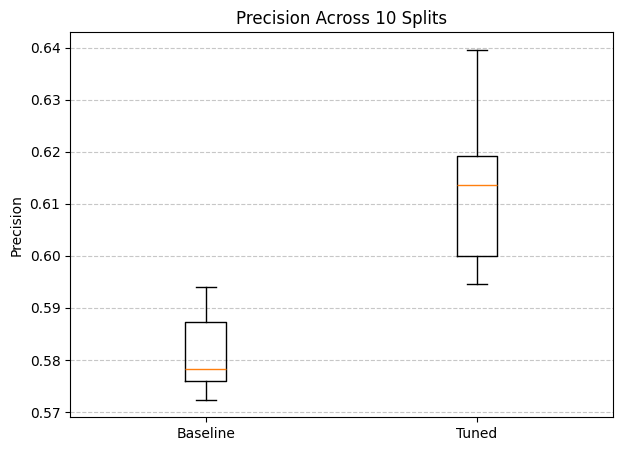

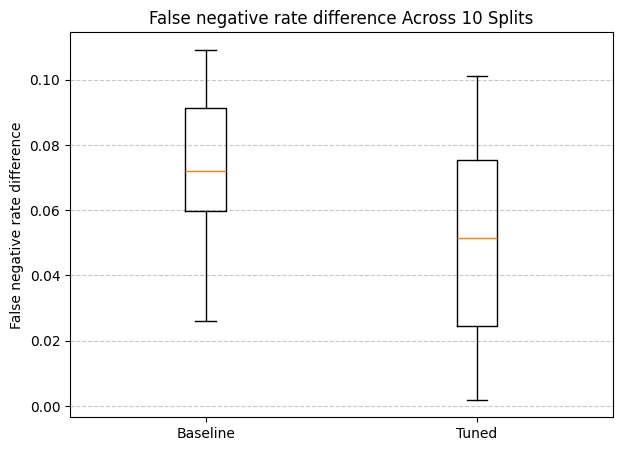

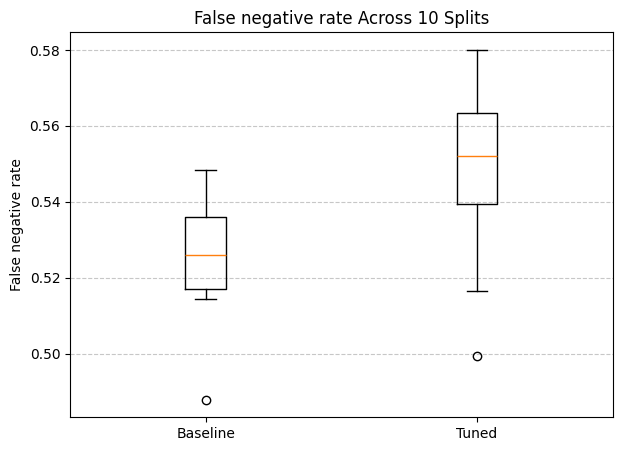

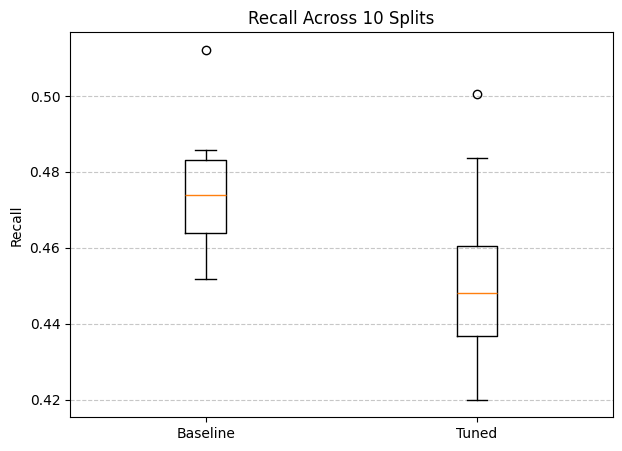

In [ ]:
#@markdown ### Boxplot tuned/untuned comparison for each metric

metric_names = list(baseline_metrics.keys())

for metric_name in metric_names:
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [baseline_metrics[metric_name], tuned_metrics[metric_name]],
        tick_labels=["Baseline", "Tuned"]
    )
    plt.title(f"{metric_name} Across {num_seeds} Splits")
    plt.ylabel(metric_name)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Problem 2, Part (c)
### **Fit Fairlean Adversarial Debiaser**

Experiment with the alpha parameter - which value of alpha produces the fairest and most accurate classifier? Does such a value exist?



Consider the Adversarial Fairness Classifier from Fairlearn, an in-processing
fairness-enhancing intervention by Zhang et. al (“Mitigating Unwanted Biases with
Adversarial Learning” 2018). This algorithm provides a parameter called alpha that
controls the tradeoff between fairness and accuracy. In this question, you will
measure the impact of alpha on fairness and accuracy.
Train four AdversarialFairnessClassifiers, each with one of the following 4 different
alpha parameter values: [0.0, 0.3, 0.7, 1.0]. Make sure to use the other
hyperparameters as stated in the notebook, to avoid poor model behavior.
Plot the same metrics as above, using box-and-whiskers plots, to show how the
metrics vary over alpha parameter settings (therefore, alpha is the x-axis). Do this
for 10 random seeds, as before (to get your error bars).
Discuss in your report how these results compare with the metrics from the tuned
random forest model from (b)

In [ ]:
#@markdown Fit the AdversarialFairnessClassifier here.
#@markdown Use these hyperparameters, while varying the `alpha` parameter:
#@markdown - backend='tensorflow',
#@markdown - predictor_model=[128,64,32,16,8],
#@markdown - adversary_model=[32,16,8],
#@markdown - learning_rate=0.001,
#@markdown - epochs=3,
#@markdown - batch_size=16,
#@markdown - constraints='demographic_parity',
#@markdown - random_state=seed,
#@markdown - shuffle=True

In [ ]:
#ACTUAL
ALPHAS = [0.0, 0.3, 0.7, 1.0]
N_SEEDS = 10
from fairlearn.metrics import selection_rate

AFC_KW = dict(
    backend="tensorflow",
    predictor_model=[128, 64, 32, 16, 8],
    adversary_model=[32, 16, 8],
    learning_rate=0.001,
    epochs=3,
    batch_size=16,
    constraints="demographic_parity",
    shuffle=True,
)

adversarial_metrics = {
    alpha: {metric: [] for metric in metrics.keys() | fairness_metrics.keys()}
    for alpha in ALPHAS
}

for i in range(N_SEEDS):
    seed = 123 + i
    print(f"Processing seed {i+1}/{N_SEEDS}")

    x_train, x_temp, y_train, y_temp = train_test_split(
        x_numeric, y_raw, test_size=0.3, random_state=seed, stratify=y_raw
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=2/3, random_state=seed, stratify=y_temp
    )

    for alpha in ALPHAS:
        print(f"  Training with alpha = {alpha}")
        clf = AdversarialFairnessClassifier(alpha=alpha, random_state=seed, **AFC_KW)
        clf.fit(x_train, y_train, sensitive_features=x_train["gender_Male"])

        y_hat = clf.predict(x_test)
        s_test = x_test["gender_Male"]

        # performance metrics
        mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_hat, sensitive_features=s_test)
        for name, val in mf.overall.items():
            adversarial_metrics[alpha][name].append(val)

        # fairness metrics
        adversarial_metrics[alpha]["False negative rate difference"].append(
            false_negative_rate_difference(y_test, y_hat, sensitive_features=s_test)
        )
        adversarial_metrics[alpha]["False positive rate difference"].append(
            false_positive_rate_difference(y_test, y_hat, sensitive_features=s_test)
        )
        adversarial_metrics[alpha]["Equalized odds ratio"].append(
            equalized_odds_ratio(y_test, y_hat, sensitive_features=s_test)
        )
        adversarial_metrics[alpha]["Selection rate difference"].append(
            selection_rate_difference(y_test, y_hat, sensitive_features=s_test)
        )

        # demographic parity difference (already in your code)
        adversarial_metrics[alpha]["Demographic parity ratio"].append(
        demographic_parity_ratio(y_test, y_hat, sensitive_features=x_test['gender_Male'])
        )

print("\nAdversarial Fairness Classifier training complete.")

Processing seed 1/10
  Training with alpha = 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdversarialFairnessClassifier was fitted without feature names
  warnings.warn(


  Training with alpha = 0.3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdversarialFairnessClassifier was fitted without feature names
  warnings.warn(


  Training with alpha = 0.7


...

  Training with alpha = 0.7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdversarialFairnessClassifier was fitted without feature names
  warnings.warn(


  Training with alpha = 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdversarialFairnessClassifier was fitted without feature names
  warnings.warn(



Adversarial Fairness Classifier training complete.


/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


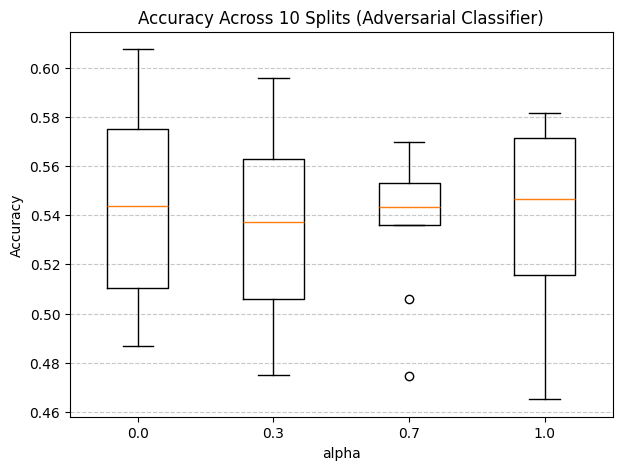

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


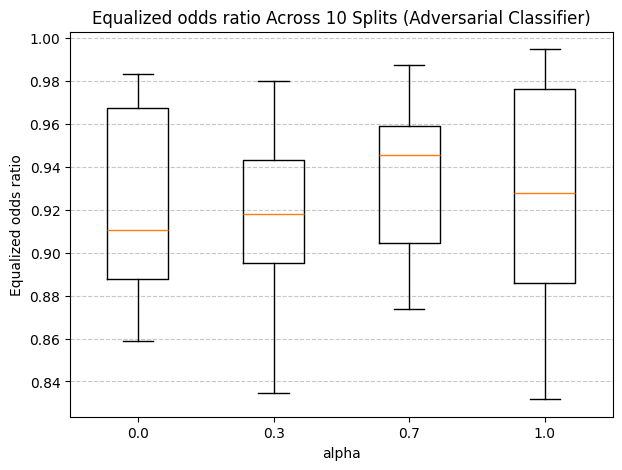

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


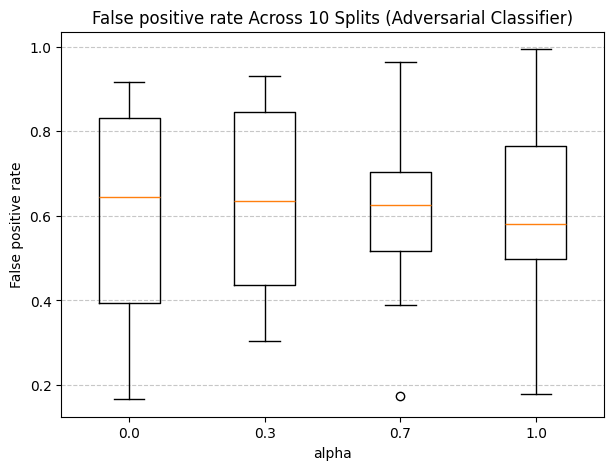

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


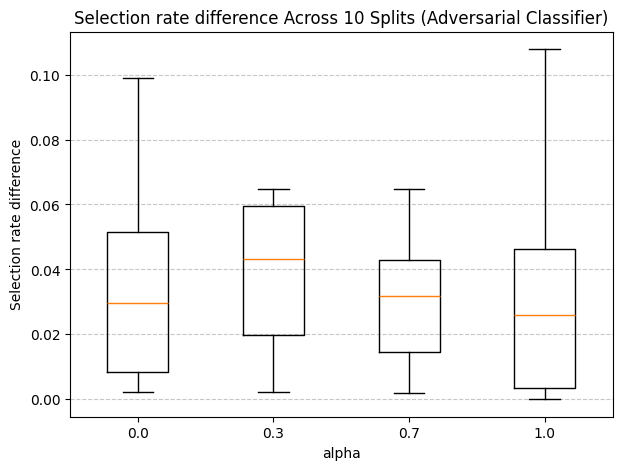

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


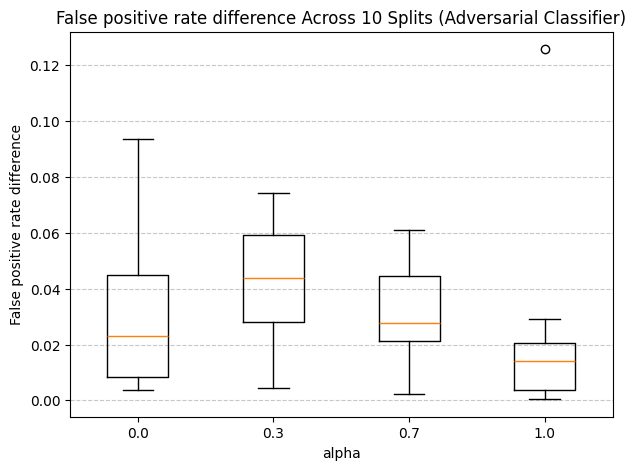

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


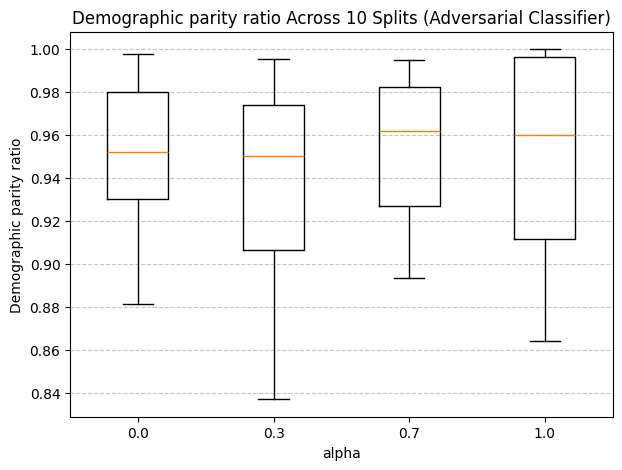

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


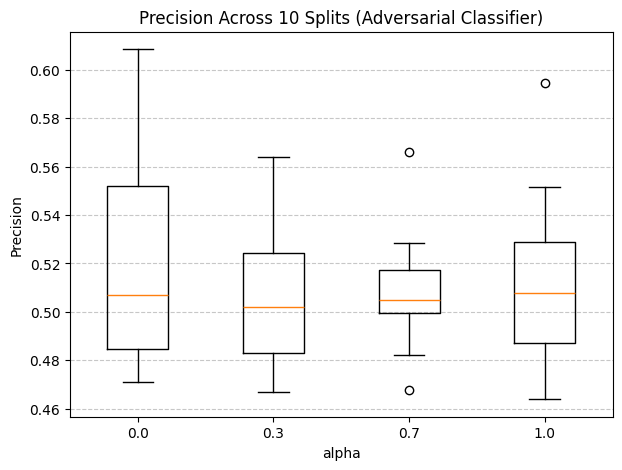

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


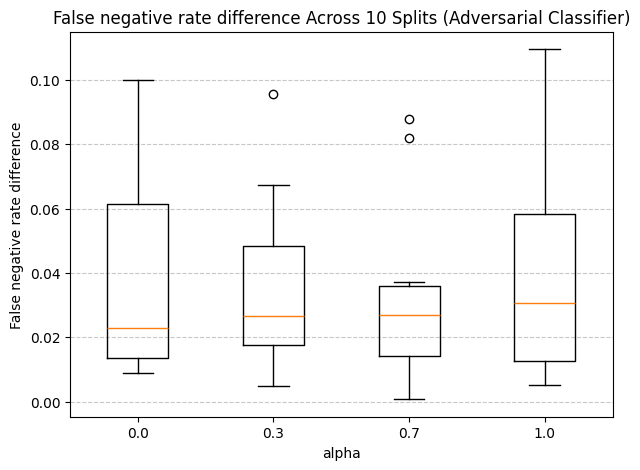

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


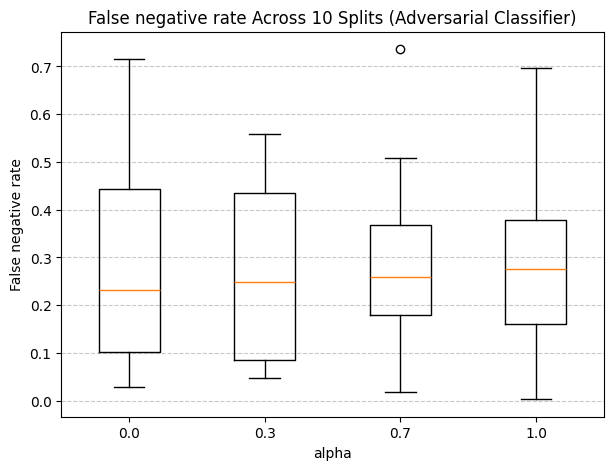

/tmp/ipython-input-1710402323.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=x_labels)


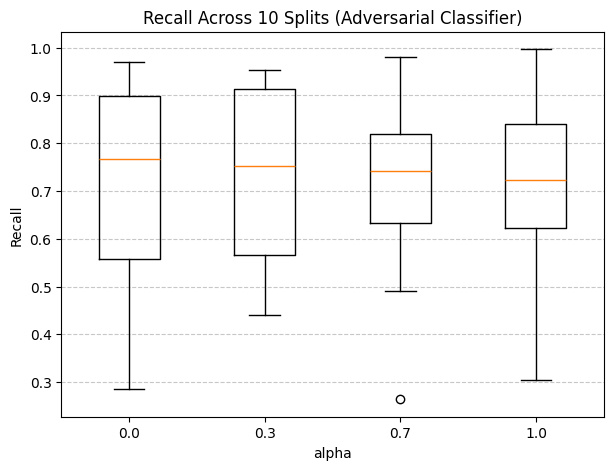

In [ ]:
#@markdown ### Plot all our metrics as box-and-whiskers plots while varying alpha


x_labels = [str(a) for a in ALPHAS]

for metric_name in adversarial_metrics[ALPHAS[0]].keys():
    data = [adversarial_metrics[a][metric_name] for a in ALPHAS]
    plt.figure(figsize=(7,5))
    plt.boxplot(data, labels=x_labels)
    plt.title(f"{metric_name} Across {N_SEEDS} Splits (Adversarial Classifier)")
    plt.xlabel("alpha")
    plt.ylabel(metric_name)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()



# Problem 2, Part (d)
### **Threshold Optimizer Post-processing intervention**



Train a classifier using ThresholdOptimizer, a post-processing algorithm by
[Hardt et. al] (“Equality of Opportunity in Supervised Learning 2016
https://arxiv.org/abs/1610.02413). (You also used this in the lab). Choose which
objective (the `constraints` parameter in the API) best fits this fair classification
scenario in the medical context, and explain why.
Do this for the same ten splits you used in part (b). Report the same set of metrics and
compare those results to your results from parts (b) and (c).
Discuss in your report how these results compare with the metrics from the tuned
random forest model from (b) and (c).


In [ ]:
threshold_optimizer_metrics = {
    **{m: [] for m in metrics.keys()},
    **{
        'False negative rate difference': [],
        'False positive rate difference': [],
        'Equalized odds ratio': [],
        'Selection rate difference': [],
        'Demographic parity difference': [],
    }
}

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    MetricFrame,
    false_negative_rate_difference,
    false_positive_rate_difference,
    equalized_odds_ratio,
    selection_rate_difference,
    demographic_parity_difference,
)

threshold_optimizer_metrics = {
    **{m: [] for m in metrics.keys()},
    **{
        'False negative rate difference': [],
        'False positive rate difference': [],
        'Equalized odds ratio': [],
        'Selection rate difference': [],
        'Demographic parity difference': [],
    }
}

for i in range(N_SEEDS):
    seed = 123 + i
    print(f"Processing seed {i+1}/{N_SEEDS}")

    x_train, x_temp, y_train, y_temp = train_test_split(
        x_numeric, y_raw, test_size=0.3, random_state=seed, stratify=y_raw
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=2/3, random_state=seed, stratify=y_temp
    )

    _, best_rf = tune_random_forest(x_train, y_train, x_val, y_val, max_depth, n_estimators)

    to = ThresholdOptimizer(
        estimator=best_rf,
        constraints="equalized_odds",
        objective="accuracy_score",
        prefit=True,
        predict_method="predict_proba"
    )
    to.fit(x_val, y_val, sensitive_features=x_val['gender_Male'])

    s_test = x_test['gender_Male']
    y_hat_to = to.predict(x_test, sensitive_features=s_test)

    mf_to = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_hat_to, sensitive_features=s_test)
    for name, val in mf_to.overall.items():
        threshold_optimizer_metrics[name].append(val)

    threshold_optimizer_metrics['False negative rate difference'].append(
        false_negative_rate_difference(y_test, y_hat_to, sensitive_features=s_test)
    )
    threshold_optimizer_metrics['False positive rate difference'].append(
        false_positive_rate_difference(y_test, y_hat_to, sensitive_features=s_test)
    )
    threshold_optimizer_metrics['Equalized odds ratio'].append(
        equalized_odds_ratio(y_test, y_hat_to, sensitive_features=s_test)
    )
    threshold_optimizer_metrics['Selection rate difference'].append(
        selection_rate_difference(y_test, y_hat_to, sensitive_features=s_test)
    )
    threshold_optimizer_metrics['Demographic parity difference'].append(
        demographic_parity_difference(y_test, y_hat_to, sensitive_features=s_test)
    )

print("\nThreshold Optimizer runs complete.")


Processing seed 1/10
Best AUC: 0.6260591452314691
Processing seed 2/10
Best AUC: 0.6551038864759332
Processing seed 3/10
Best AUC: 0.666755939558371
Processing seed 4/10
Best AUC: 0.6491264841618246
Processing seed 5/10
Best AUC: 0.6706179624820969
Processing seed 6/10
Best AUC: 0.64467836529691
Processing seed 7/10
Best AUC: 0.6362478991759725
Processing seed 8/10
Best AUC: 0.6585622406719532
Processing seed 9/10
Best AUC: 0.6575336617023176
Processing seed 10/10
Best AUC: 0.661170561681746

Threshold Optimizer runs complete.


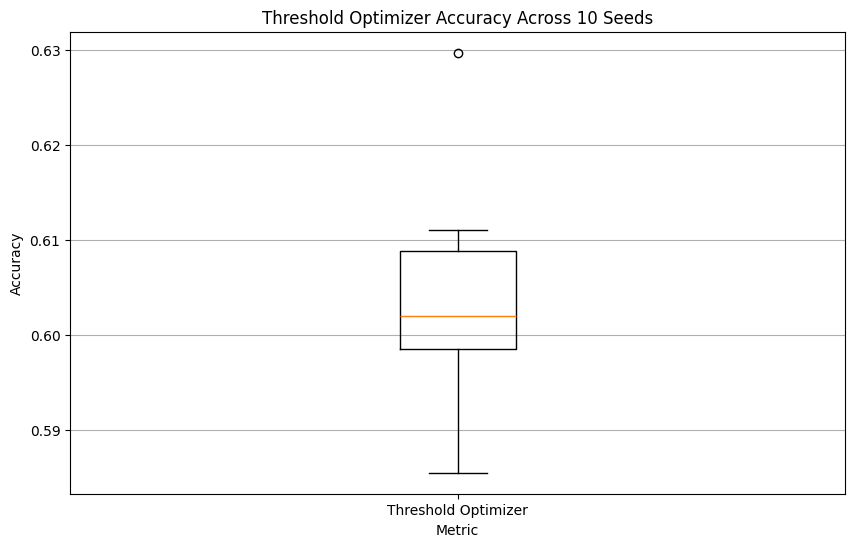

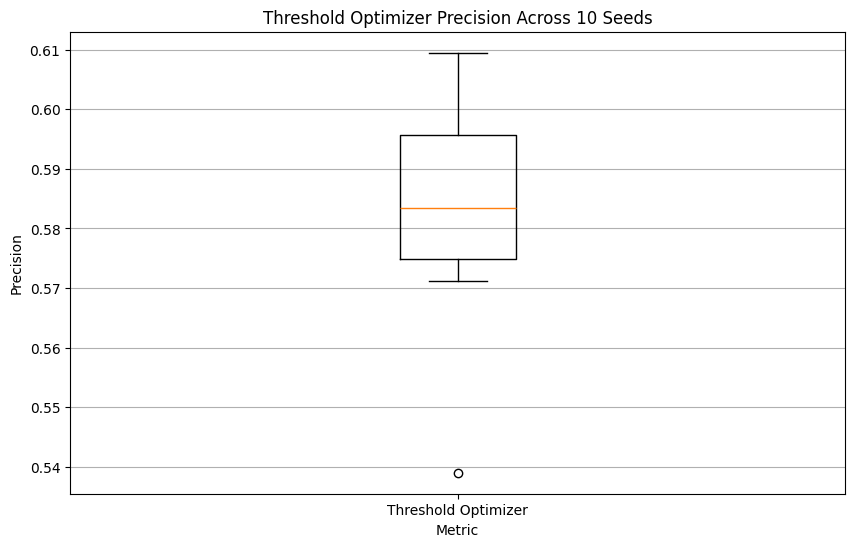

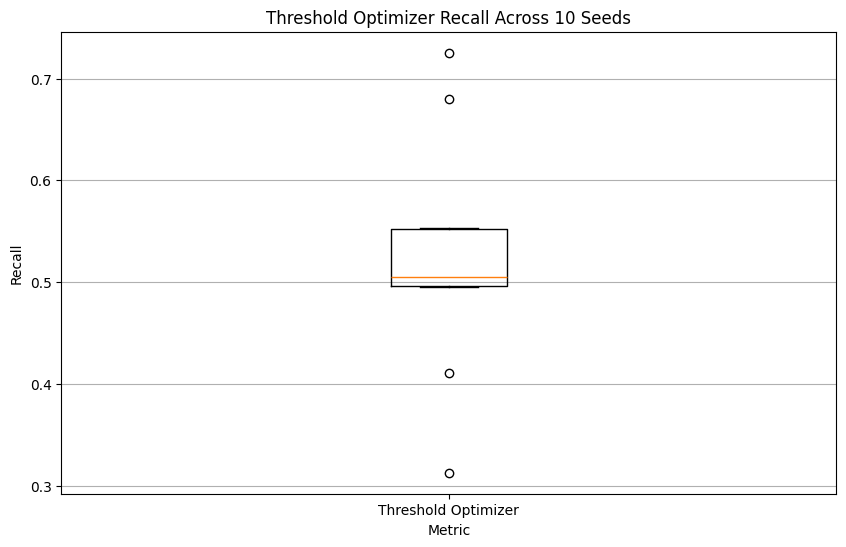

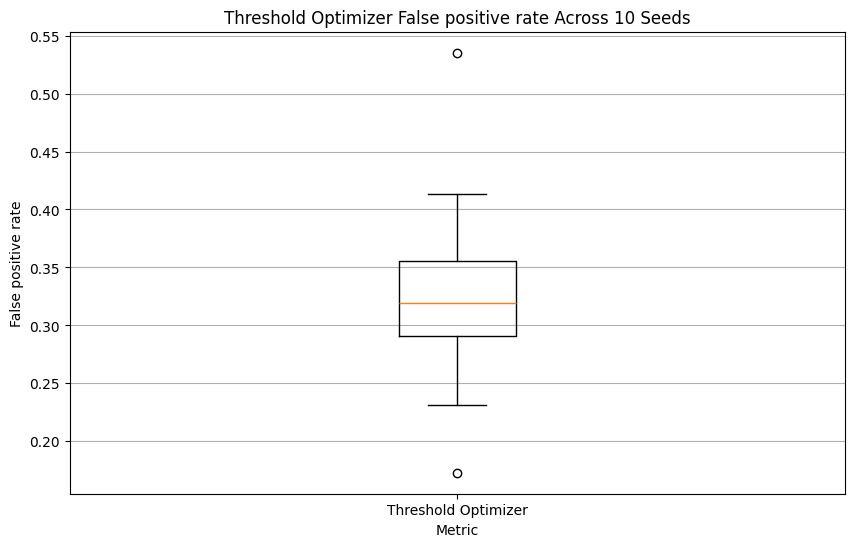

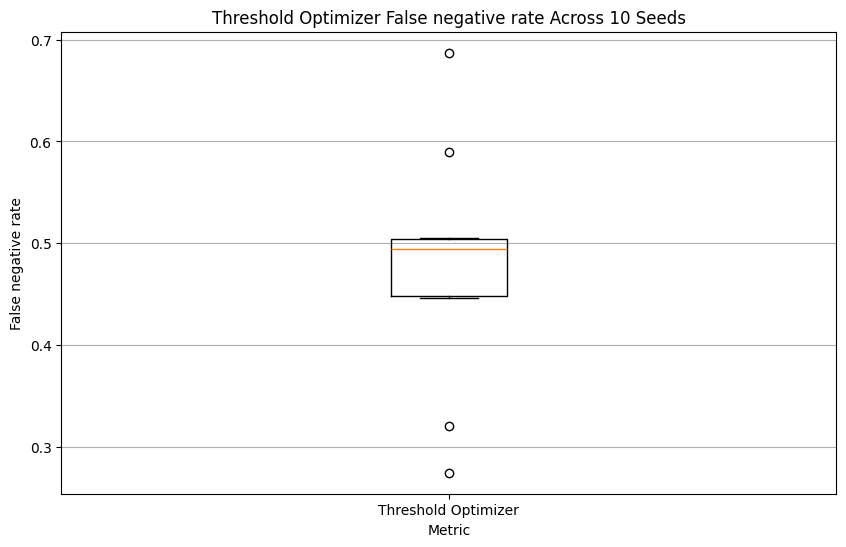

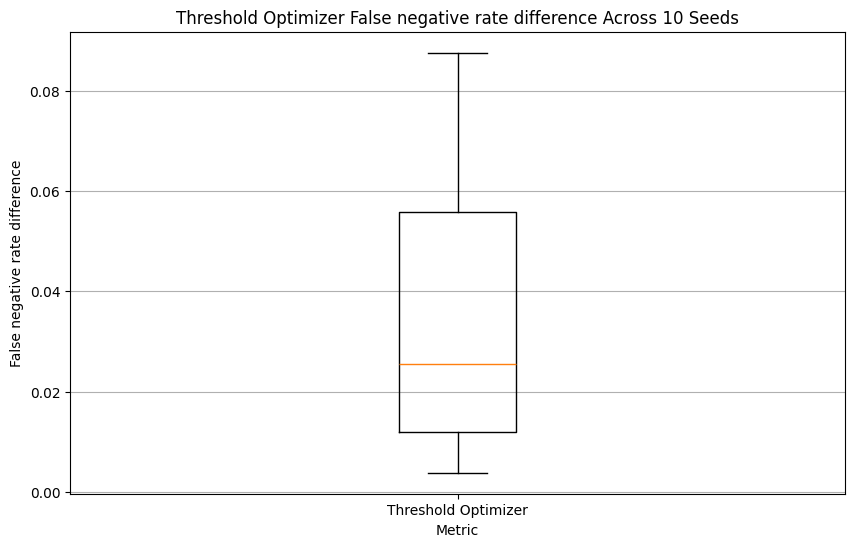

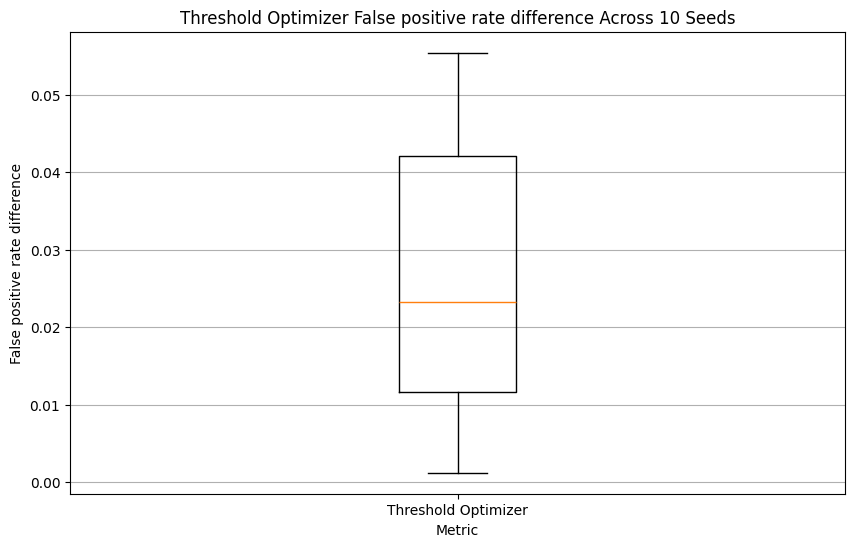

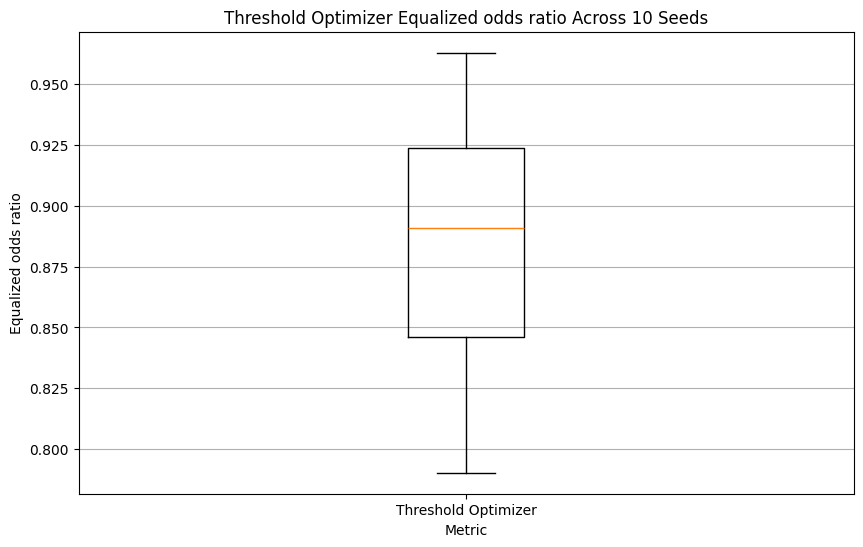

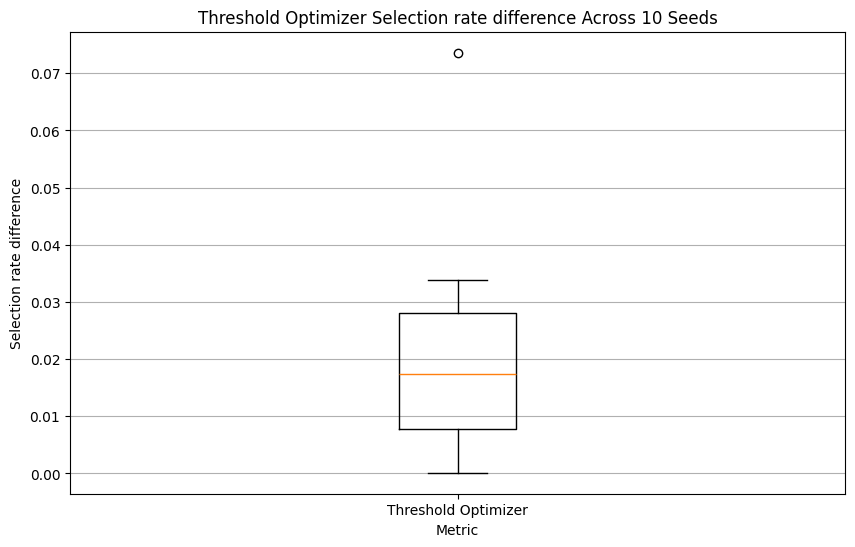

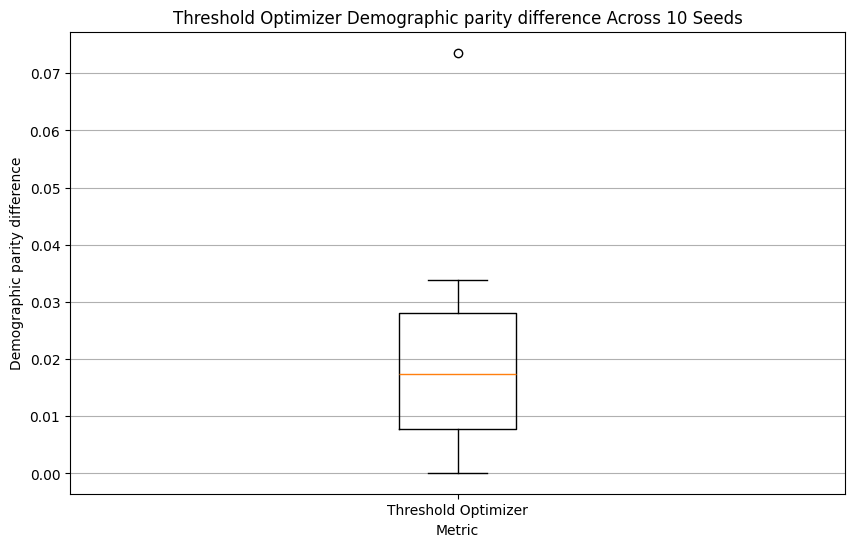

In [ ]:
# Get the list of metrics to plot
metric_names = list(threshold_optimizer_metrics.keys())

# Plot boxplots for each metric
for metric_name in metric_names:
    plt.figure(figsize=(10, 6))
    data_to_plot = [threshold_optimizer_metrics[metric_name]]
    plt.boxplot(data_to_plot, tick_labels=["Threshold Optimizer"])
    plt.title(f"Threshold Optimizer {metric_name} Across {N_SEEDS} Seeds")
    plt.xlabel("Metric")
    plt.ylabel(metric_name)
    plt.grid(axis='y')
    plt.show()

In [ ]:

print("Average Metrics Across 10 Seeds:")

print("\nBaseline Random Forest:")
for metric_name in baseline_metrics.keys():
    avg_metric = np.mean(baseline_metrics[metric_name])
    print(f"  {metric_name}: {avg_metric:.4f}")

print("\nTuned Random Forest:")
for metric_name in tuned_metrics.keys():
    avg_metric = np.mean(tuned_metrics[metric_name])
    print(f"  {metric_name}: {avg_metric:.4f}")

print("\nAdversarial Fairness Classifier:")
for alpha in ALPHAS:
    print(f"  Alpha = {alpha}:")
    for metric_name in adversarial_metrics[alpha].keys():
        avg_metric = np.mean(adversarial_metrics[alpha][metric_name])
        print(f"    {metric_name}: {avg_metric:.4f}")

print("\nThreshold Optimizer:")
for metric_name in threshold_optimizer_metrics.keys():
    avg_metric = np.mean(threshold_optimizer_metrics[metric_name])
    print(f"  {metric_name}: {avg_metric:.4f}")


Average Metrics Across 10 Seeds:

Baseline Random Forest:
  Accuracy: 0.5985
  Equalized odds ratio: 0.8059
  False positive rate: 0.2952
  Selection rate difference: 0.0717
  False positive rate difference: 0.0583
  Demographic parity ratio: 0.8261
  Precision: 0.5813
  False negative rate difference: 0.0725
  False negative rate: 0.5247
  Recall: 0.4753

Tuned Random Forest:
  Accuracy: 0.6139
  Equalized odds ratio: 0.8294
  False positive rate: 0.2468
  Selection rate difference: 0.0538
  False positive rate difference: 0.0412
  Demographic parity ratio: 0.8543
  Precision: 0.6127
  False negative rate difference: 0.0518
  False negative rate: 0.5475
  Recall: 0.4525

Adversarial Fairness Classifier:
  Alpha = 0.0:
    Accuracy: 0.5443
    Equalized odds ratio: 0.9212
    False positive rate: 0.5960
    Selection rate difference: 0.0342
    False positive rate difference: 0.0332
    Demographic parity ratio: 0.9492
    Precision: 0.5228
    False negative rate difference: 0.0384
  